<h1 style="text-align:center; color:#0f172a;">
📊 Impact of Medications on Diabetic Patient Outcomes
</h1>

<p style="text-align:center;">
Analyzing treatment effectiveness and patient outcomes
</p>

> ## 🔴 Project Statement  
>  
> Diabetes is a chronic disease requiring continuous monitoring and medication.  
> Variations in medication usage can lead to different patient outcomes, including hospital readmissions.  
>  
> **This project focuses on analyzing how medications impact patient outcomes and identifying patterns to support better treatment decisions.**

> ## 🔴 Project Objectives  
>
> - Analyze diabetic patient data using Python  
> - Identify patterns in medication usage  
> - Study the relationship between medications and patient outcomes  
> - Explore factors influencing hospital readmissions  
> - Present insights in a clear and meaningful way  

> ## 🔴 Aim of the Project  
>  
> The aim of this project is to evaluate the impact of medications on diabetic patient outcomes.  
>  
> **It focuses on generating data-driven insights to improve treatment effectiveness and reduce hospital readmissions.**

## 🔴 Dataset Overview  
>  
> The dataset consists of records of diabetic patients, covering demographic details, medical test results, medications, and hospital visit information.  
>  
> **It includes key attributes such as age, gender, admission type, medications, and readmission status, making it ideal for exploratory data analysis.**)

## ⚙️ Setup & Configuration  
>  
> This section outlines the environment setup, required libraries, and initial configurations used in the project.

In [61]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [62]:
# Load the dataset

df = pd.read_csv(r"C:\Users\thoma\Desktop\diabetics records.csv")

In [63]:
# Basic dataset information

print(f"Total Rows: {df.shape[0]} | Total Columns: {df.shape[1]}")
display(df.info())

Total Rows: 101766 | Total Columns: 50
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      101766 non-null  object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    101766 non-null  object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                101766 non-null  object
 11  medical_specialty         101766 non-null  object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures      

None

In [64]:
# First few rows

df.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


<div style="background-color:#d6ecff; padding:10px; border-radius:5px;">
<b style="color:black; font-size:18px;">📊 Dataset Description Table</b>
</div>

<table border="1" style="border-collapse:collapse; width:100%; text-align:left;">
<tr style="background-color:#f2f2f2;">
<th>Variable Name</th>
<th>Role</th>
<th>Type</th>
<th>Demographic</th>
<th>Description</th>
</tr>

<tr>
<td>encounter_id</td>
<td>ID</td>
<td>-</td>
<td>-</td>
<td>Unique identifier of an encounter</td>
</tr>

<tr>
<td>patient_nbr</td>
<td>ID</td>
<td>-</td>
<td>-</td>
<td>Unique identifier of a patient</td>
</tr>

<tr>
<td>race</td>
<td>Feature</td>
<td>Categorical</td>
<td>Race</td>
<td>Caucasian, Asian, African American, Hispanic, Other</td>
</tr>

<tr>
<td>gender</td>
<td>Feature</td>
<td>Categorical</td>
<td>Gender</td>
<td>Male, Female, Unknown</td>
</tr>

<tr>
<td>age</td>
<td>Feature</td>
<td>Categorical</td>
<td>Age</td>
<td>Grouped in 10-year intervals</td>
</tr>

<tr>
<td>time_in_hospital</td>
<td>Feature</td>
<td>Integer</td>
<td>-</td>
<td>Number of days between admission and discharge</td>
</tr>

<tr>
<td>num_lab_procedures</td>
<td>Feature</td>
<td>Integer</td>
<td>-</td>
<td>Number of lab tests performed</td>
</tr>

<tr>
<td>num_procedures</td>
<td>Feature</td>
<td>Integer</td>
<td>-</td>
<td>Number of procedures performed</td>
</tr>

<tr>
<td>num_medications</td>
<td>Feature</td>
<td>Integer</td>
<td>-</td>
<td>Number of medications administered</td>
</tr>

<tr>
<td>number_outpatient</td>
<td>Feature</td>
<td>Integer</td>
<td>-</td>
<td>Outpatient visits in previous year</td>
</tr>

<tr>
<td>number_emergency</td>
<td>Feature</td>
<td>Integer</td>
<td>-</td>
<td>Emergency visits in previous year</td>
</tr>

<tr>
<td>number_inpatient</td>
<td>Feature</td>
<td>Integer</td>
<td>-</td>
<td>Inpatient visits in previous year</td>
</tr>

<tr>
<td>insulin</td>
<td>Feature</td>
<td>Categorical</td>
<td>-</td>
<td>Indicates insulin usage (up, down, steady, no)</td>
</tr>

<tr>
<td>diabetesMed</td>
<td>Feature</td>
<td>Categorical</td>
<td>-</td>
<td>Indicates if diabetic medication was prescribed (Yes/No)</td>
</tr>

<tr>
<td>readmitted</td>
<td>Target</td>
<td>Categorical</td>
<td>-</td>
<td>Readmission status (&lt;30, &gt;30, No)</td>
</tr>

</table>

In [65]:
# Check missing values
df.isnull().sum()

encounter_id                    0
patient_nbr                     0
race                            0
gender                          0
age                             0
weight                          0
admission_type_id               0
discharge_disposition_id        0
admission_source_id             0
time_in_hospital                0
payer_code                      0
medical_specialty               0
num_lab_procedures              0
num_procedures                  0
num_medications                 0
number_outpatient               0
number_emergency                0
number_inpatient                0
diag_1                          0
diag_2                          0
diag_3                          0
number_diagnoses                0
max_glu_serum               96420
A1Cresult                   84748
metformin                       0
repaglinide                     0
nateglinide                     0
chlorpropamide                  0
glimepiride                     0
acetohexamide 

<h2 style="text-align:center; color:red;">
Phase 2: Data Cleaning & Preprocessing
</h2>

In [66]:
# Remove duplicate rows
df = df.drop_duplicates()

print("Duplicates removed. New shape:", df.shape)

Duplicates removed. New shape: (101766, 50)


In [67]:
df = df.dropna()

In [68]:
# Fill numerical columns
num_cols = df.select_dtypes(include=['int64','float64']).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# Fill categorical columns (FIXED)
cat_cols = df.select_dtypes(include=['object']).columns

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [69]:
# Check data types
df.dtypes

encounter_id                 int64
patient_nbr                  int64
race                        object
gender                      object
age                         object
weight                      object
admission_type_id            int64
discharge_disposition_id     int64
admission_source_id          int64
time_in_hospital             int64
payer_code                  object
medical_specialty           object
num_lab_procedures           int64
num_procedures               int64
num_medications              int64
number_outpatient            int64
number_emergency             int64
number_inpatient             int64
diag_1                      object
diag_2                      object
diag_3                      object
number_diagnoses             int64
max_glu_serum               object
A1Cresult                   object
metformin                   object
repaglinide                 object
nateglinide                 object
chlorpropamide              object
glimepiride         

In [70]:
# Example conversions (modify based on your dataset)
# df['age'] = df['age'].astype(int)
# df['date'] = pd.to_datetime(df['date'])

In [71]:
# Standardize column names
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

In [72]:
df['age'].unique()

array(['[80-90)', '[40-50)', '[70-80)', '[50-60)', '[30-40)', '[60-70)',
       '[20-30)', '[10-20)'], dtype=object)

In [73]:
def convert_age(age_range):
    if pd.isna(age_range):
        return None
    age_range = age_range.strip('[]()')
    low, high = age_range.split('-')
    return (int(low) + int(high)) / 2

df['age_numeric'] = df['age'].apply(convert_age)

In [74]:
df['age_group'] = pd.cut(df['age_numeric'],
                        bins=[0, 30, 50, 70, 100],
                        labels=['Young', 'Adult', 'Senior', 'Elder'])

In [75]:
print(df.isnull().sum())
print(df.shape)
df.head()

encounter_id                0
patient_nbr                 0
race                        0
gender                      0
age                         0
weight                      0
admission_type_id           0
discharge_disposition_id    0
admission_source_id         0
time_in_hospital            0
payer_code                  0
medical_specialty           0
num_lab_procedures          0
num_procedures              0
num_medications             0
number_outpatient           0
number_emergency            0
number_inpatient            0
diag_1                      0
diag_2                      0
diag_3                      0
number_diagnoses            0
max_glu_serum               0
a1cresult                   0
metformin                   0
repaglinide                 0
nateglinide                 0
chlorpropamide              0
glimepiride                 0
acetohexamide               0
glipizide                   0
glyburide                   0
tolbutamide                 0
pioglitazo

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesmed,readmitted,age_numeric,age_group
162,2521974,80499960,Caucasian,Male,[80-90),?,6,3,7,5,...,No,No,No,No,No,No,No,<30,85.0,Elder
192,2595612,89193870,Caucasian,Female,[40-50),?,6,1,7,2,...,No,No,No,No,No,No,No,>30,45.0,Adult
460,4084524,76959585,AfricanAmerican,Female,[70-80),?,6,1,7,10,...,No,No,No,No,No,Ch,Yes,>30,75.0,Elder
593,4804968,114960726,Caucasian,Female,[50-60),?,6,1,7,2,...,No,No,No,No,No,No,Yes,NO,55.0,Senior
696,5319174,87847776,Other,Male,[70-80),?,6,6,7,11,...,No,No,No,No,No,No,Yes,NO,75.0,Elder


In [76]:
df['race'] = df['race'].replace('?', 'No data available')

In [77]:
df['weight'] = df['weight'].replace('?', '[80-100)')
df['weight'] = df['weight'].fillna('[80-100)')

In [78]:
df['payer_code'] = df['payer_code'].replace('?', 'No data available')

In [79]:
df['medical_specialty'] = df['medical_specialty'].replace('?', 'No data available')

In [80]:
import numpy as np

df['diag_2'] = df['diag_2'].replace('?', np.nan)
df['diag_3'] = df['diag_3'].replace('?', np.nan)

In [81]:
df['diag_2'] = df['diag_2'].fillna(df['diag_2'].mode()[0])
df['diag_3'] = df['diag_3'].fillna(df['diag_3'].mode()[0])

In [82]:
df[['diag_2','diag_3']] = df[['diag_2','diag_3']].replace('?', np.nan)

for col in ['diag_2', 'diag_3']:
    df[col] = df[col].fillna(df[col].mode()[0])

In [83]:
print(df['diag_1'].unique()[:10])
print(df['diag_2'].unique()[:10])
print(df['diag_3'].unique()[:10])

['332' '250.02' '276' '820' '296' '428' '250.03' '295' '682' '715']
['294' '401' '276' '780' '250.02' '250' '250.03' '493' '599' '402']
['425' '250' '294' '250.03' 'E885' '564' '276' '272' '300' '891']


In [84]:
df[['diag_2','diag_3']].isnull().sum()

diag_2    0
diag_3    0
dtype: int64

In [85]:
df['diag_1'].value_counts().head()

diag_1
491    21
428    19
682    19
414    14
786    12
Name: count, dtype: int64

In [86]:
from IPython.display import display
display(df[['diag_1','diag_2','diag_3']].head(10))

,diag_1,diag_2,diag_3
162,332,294,425
192,250.02,401,250
460,250.02,276,294
593,276,780,250.03
696,820,250.02,E885
771,296,250,564
823,428,250.02,276
961,250.03,401,272
1280,295,276,300
1755,682,250.03,891


In [87]:
(df[['diag_1','diag_2','diag_3']] == '?').sum()

diag_1    0
diag_2    0
diag_3    0
dtype: int64

In [88]:
df[['diag_1','diag_2','diag_3']].isnull().sum()

diag_1    0
diag_2    0
diag_3    0
dtype: int64

In [89]:
from IPython.display import display

display(df.head(10))

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesmed,readmitted,age_numeric,age_group
162,2521974,80499960,Caucasian,Male,[80-90),[80-100),6,3,7,5,...,No,No,No,No,No,No,No,<30,85.0,Elder
192,2595612,89193870,Caucasian,Female,[40-50),[80-100),6,1,7,2,...,No,No,No,No,No,No,No,>30,45.0,Adult
460,4084524,76959585,AfricanAmerican,Female,[70-80),[80-100),6,1,7,10,...,No,No,No,No,No,Ch,Yes,>30,75.0,Elder
593,4804968,114960726,Caucasian,Female,[50-60),[80-100),6,1,7,2,...,No,No,No,No,No,No,Yes,NO,55.0,Senior
696,5319174,87847776,Other,Male,[70-80),[80-100),6,6,7,11,...,No,No,No,No,No,No,Yes,NO,75.0,Elder
771,5993358,60354486,Caucasian,Female,[30-40),[80-100),6,1,2,14,...,No,No,No,No,No,No,No,>30,35.0,Adult
823,6479016,20676798,Caucasian,Male,[80-90),[80-100),6,1,7,7,...,No,No,No,No,No,No,Yes,>30,85.0,Elder
961,7296540,56993832,Hispanic,Female,[50-60),[80-100),6,1,7,2,...,No,No,No,No,No,No,Yes,<30,55.0,Senior
1280,9030192,108960345,Caucasian,Female,[40-50),[80-100),6,1,7,3,...,No,No,No,No,No,Ch,Yes,>30,45.0,Adult
1755,11573118,82255599,Caucasian,Female,[50-60),[80-100),6,1,7,2,...,No,No,No,No,No,No,No,>30,55.0,Senior


In [90]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
print(num_cols)

Index(['encounter_id', 'patient_nbr', 'admission_type_id',
       'discharge_disposition_id', 'admission_source_id', 'time_in_hospital',
       'num_lab_procedures', 'num_procedures', 'num_medications',
       'number_outpatient', 'number_emergency', 'number_inpatient',
       'number_diagnoses', 'age_numeric'],
      dtype='object')


In [91]:
Q1 = df[num_cols].quantile(0.25)
Q3 = df[num_cols].quantile(0.75)
IQR = Q3 - Q1

outliers = ((df[num_cols] < (Q1 - 1.5 * IQR)) | 
            (df[num_cols] > (Q3 + 1.5 * IQR)))

print(outliers.sum())  # count of outliers per column

encounter_id                 5
patient_nbr                  4
admission_type_id           58
discharge_disposition_id    14
admission_source_id         25
time_in_hospital             5
num_lab_procedures           2
num_procedures               3
num_medications              2
number_outpatient           23
number_emergency            17
number_inpatient            25
number_diagnoses            67
age_numeric                  4
dtype: int64


In [92]:
for col in num_cols:
    median = df[col].median()
    lower = Q1[col] - 1.5 * IQR[col]
    upper = Q3[col] + 1.5 * IQR[col]
    
    df.loc[(df[col] < lower) | (df[col] > upper), col] = median

C:\Users\thoma\AppData\Local\Temp\ipykernel_8920\1151003902.py:6: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '63.5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[(df[col] < lower) | (df[col] > upper), col] = median
C:\Users\thoma\AppData\Local\Temp\ipykernel_8920\1151003902.py:6: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '13.5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[(df[col] < lower) | (df[col] > upper), col] = median


In [93]:
df[num_cols].head()

,encounter_id,patient_nbr,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses,age_numeric
162,2521974,80499960,6,3,7,5,47.0,1,6.0,0,0,0,5,85.0
192,2595612,89193870,6,1,7,2,53.0,0,4.0,0,0,0,6,45.0
460,4084524,76959585,6,1,7,10,72.0,1,19.0,0,0,0,5,75.0
593,4804968,114960726,6,1,7,2,61.0,0,5.0,0,0,0,5,55.0
696,5319174,87847776,6,6,7,11,71.0,1,20.0,0,0,0,5,75.0


> ## 🔴 Cleaning – Overview  
>  
> The data cleaning process was carried out to improve data quality and ensure accurate analysis. Key steps include:  
>  
> - Removal of duplicate records to eliminate redundancy  
> - Handling of missing values across multiple columns  
> - Creation of new features: **`age_numeric`** and **`age_group`**  
> - Replacement of `'?'` values with **"No data available"** in categorical columns  
> - Standardization of column names for consistency  
> - Correction of data types for proper analysis
> - Outliers were detected using the IQR method and handled by limiting extreme values

<h2 style="text-align:center; color:red;">
Phase 3:  Exploratory Data Analysis (EDA) 
</h2>

<h2 style="text-align:Left corner; color:Black;">
🔷Univariate Analysis (Single variable) 
</h2>

<h3 style="text-align:Left corner; color:Black;">
 Age Distribution
</h3>

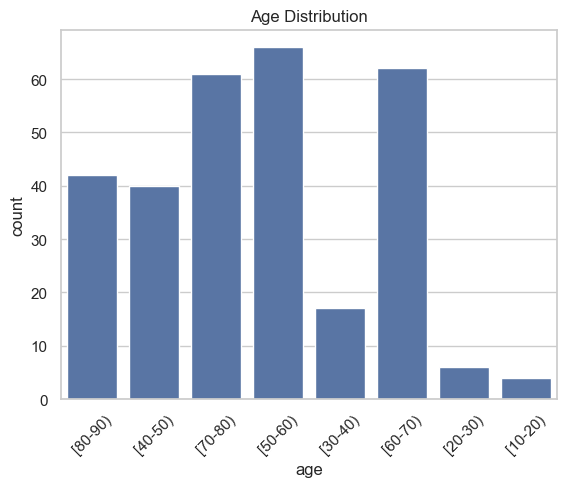

In [94]:
sns.countplot(x='age', data=df)
plt.xticks(rotation=45)
plt.title("Age Distribution")
plt.show()

<h3 style="text-align:Left corner; color:Black;">
Gender
</h3>

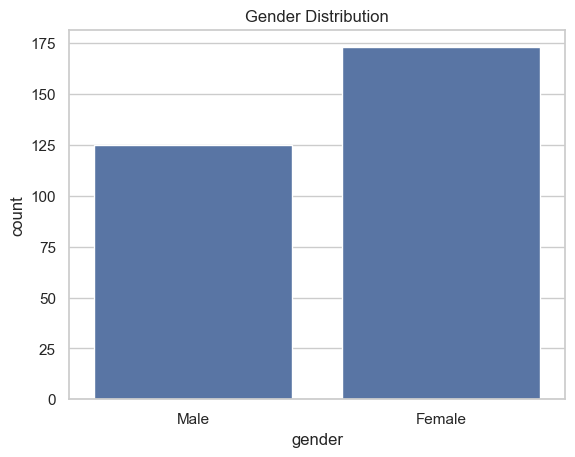

In [95]:
sns.countplot(x='gender', data=df)
plt.title("Gender Distribution")
plt.show()

<h3 style="text-align:Left corner; color:Black;">
Time in Hospital
</h3>

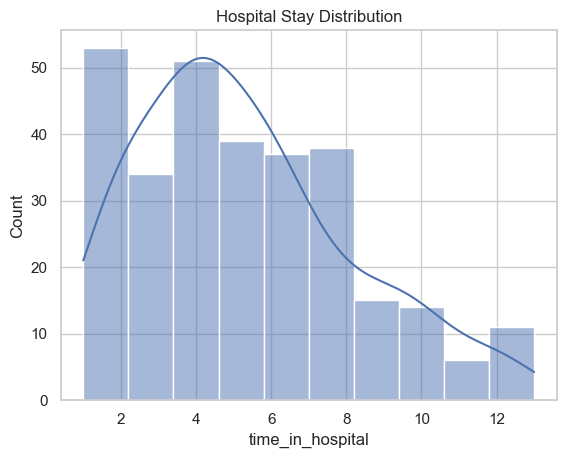

In [96]:
sns.histplot(df['time_in_hospital'], bins=10, kde=True)
plt.title("Hospital Stay Distribution")
plt.show()

<h2 style="text-align:Left corner; color:Black;">
🔷Bivariate Analysis (2 variables) 
</h2>

<h3 style="text-align:Left corner; color:Black;">
Gender vs Hospital Stay
</h3>

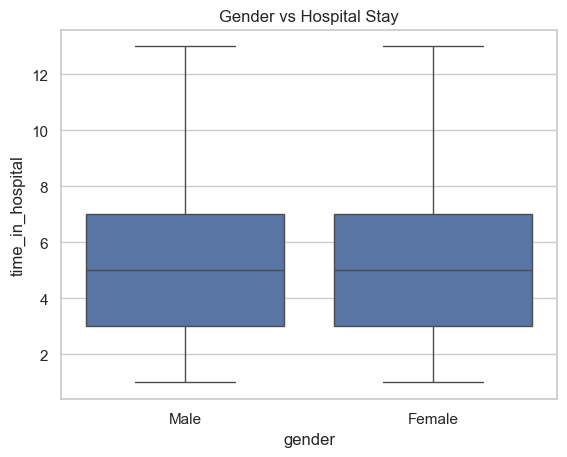

In [97]:
sns.boxplot(x='gender', y='time_in_hospital', data=df)
plt.title("Gender vs Hospital Stay")
plt.show()

<h3 style="text-align:Left corner; color:Black;">
Age vs Readmission
</h3

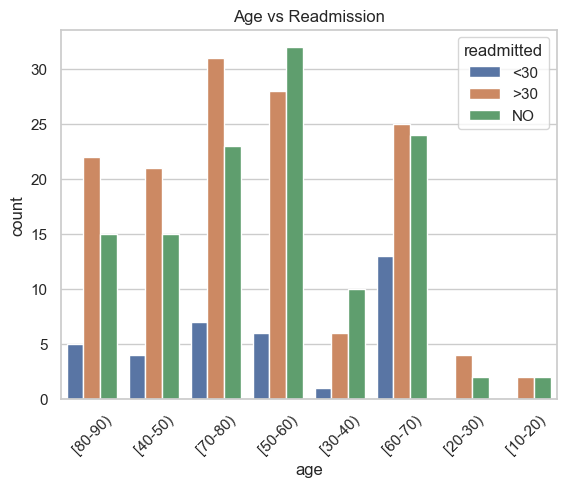

In [98]:
sns.countplot(x='age', hue='readmitted', data=df)
plt.xticks(rotation=45)
plt.title("Age vs Readmission")
plt.show()

<h3 style="text-align:Left corner; color:Black;">
Diabetes Medication vs Readmission
</h3

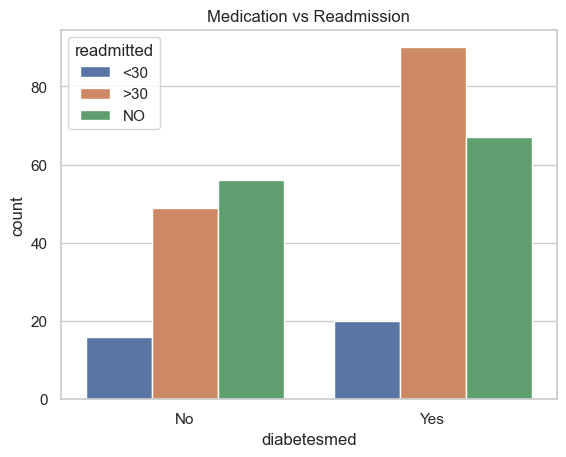

In [99]:
sns.countplot(x='diabetesmed', hue='readmitted', data=df)
plt.title("Medication vs Readmission")
plt.show()

<h2 style="text-align:Left corner; color:Black;">
🔷Multivariate Analysis (3+ variables)
</h2>

<h3 style="text-align:Left corner; color:Black;">
Correlation Heatmap
</h3

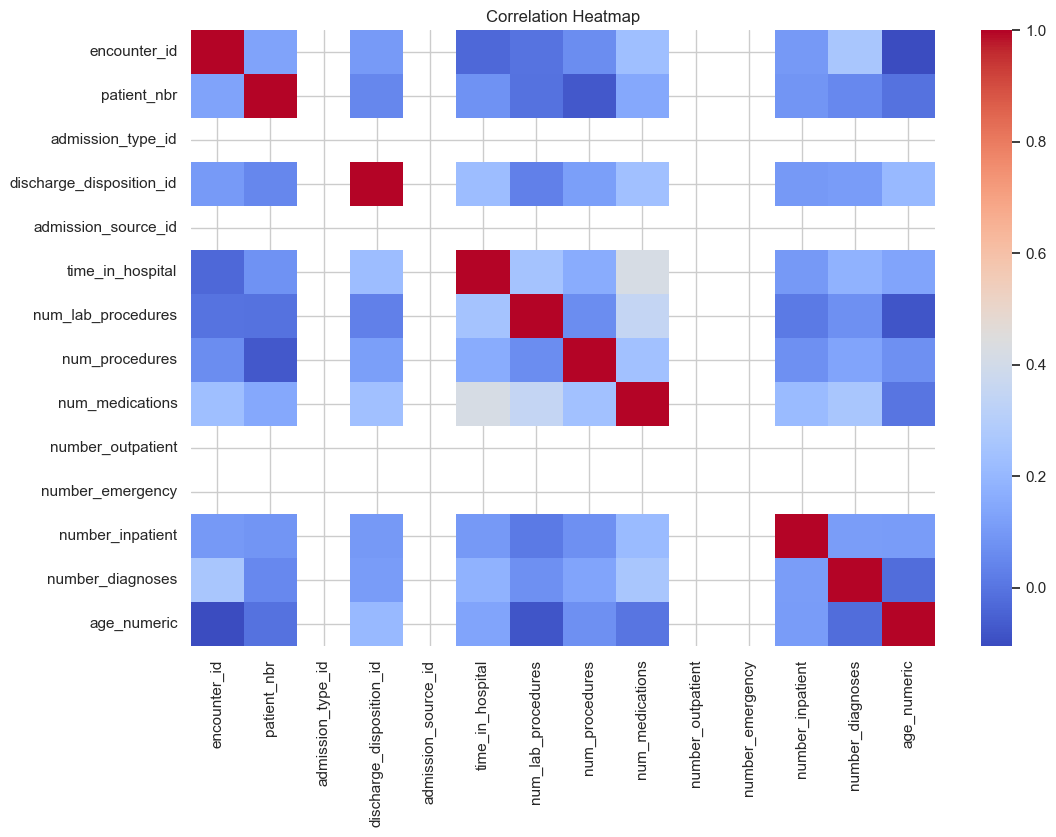

In [100]:
plt.figure(figsize=(12,8))
sns.heatmap(df.select_dtypes(include=['int64','float64']).corr(), annot=False, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

<h3 style="text-align:Left corner; color:Black;">
GroupBy Analysis
</h3>

In [101]:
df.groupby('age')['time_in_hospital'].mean()

age
[10-20)    4.000000
[20-30)    4.500000
[30-40)    4.764706
[40-50)    5.200000
[50-60)    4.681818
[60-70)    5.500000
[70-80)    5.377049
[80-90)    6.166667
Name: time_in_hospital, dtype: float64

<h3 style="text-align:Left corner; color:Black;">
Pivot Table
</h3>

In [102]:
pivot = pd.pivot_table(df,
                       values='time_in_hospital',
                       index='age',
                       columns='gender',
                       aggfunc='mean')

print(pivot)

gender     Female      Male
age                        
[10-20)  2.000000  4.666667
[20-30)  4.200000  6.000000
[30-40)  4.555556  5.000000
[40-50)  5.400000  5.000000
[50-60)  4.631579  4.750000
[60-70)  5.586207  5.424242
[70-80)  5.275000  5.571429
[80-90)  6.032258  6.545455


<h2 style="text-align:Left corner; color:Black;">
🔷Statistical Summary
</h2>

In [103]:
df['time_in_hospital'].describe()

count    298.000000
mean       5.265101
std        2.852170
min        1.000000
25%        3.000000
50%        5.000000
75%        7.000000
max       13.000000
Name: time_in_hospital, dtype: float64

<h2 style="text-align:center; color:red;">
Phase 4:   Visualizations 
</h2>

<h2 style="text-align:Left corner; color:Black;">
 🎯 1. Patient Demographics Analysis 
</h2>

<h3 style="text-align:Left corner; color:Black;">
 ❓ What is the distribution of patients across different age groups? 
</h3>

([0, 1, 2, 3, 4, 5, 6, 7],
 [Text(0, 0, '[80-90)'),
  Text(1, 0, '[40-50)'),
  Text(2, 0, '[70-80)'),
  Text(3, 0, '[50-60)'),
  Text(4, 0, '[30-40)'),
  Text(5, 0, '[60-70)'),
  Text(6, 0, '[20-30)'),
  Text(7, 0, '[10-20)')])

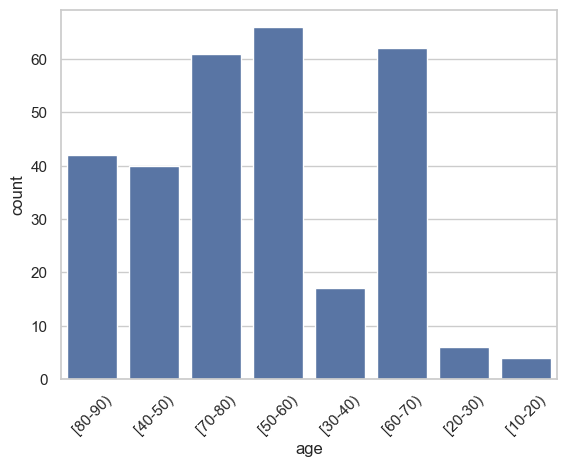

In [104]:
sns.countplot(x='age', data=df)
plt.xticks(rotation=45)

<h4 style="text-align:Left corner; color:Black;">
 The analysis clearly shows that patient concentration increases with age, peaking in the 70–80 group, and then declines in very old age. This highlights the significant impact of aging on healthcare demand and the need for targeted medical support for older populations. 
</h4>

<h3 style="text-align:Left corner; color:Black;">
 ❓ How does patient distribution vary by gender? 
</h3>

<Axes: xlabel='gender', ylabel='count'>

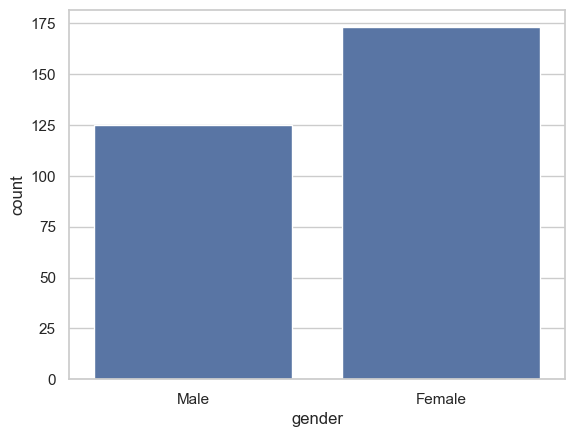

In [105]:
sns.countplot(x='gender', data=df)

<h4 style="text-align:Left corner; color:Black;">
 While both males and females significantly contribute to hospital admissions, females represent the larger share, which may be influenced by factors such as healthcare-seeking behavior, demographic composition, or gender-specific health needs.
</h4>

<h3 style="text-align:Left corner; color:Black;">
 ❓ What is the racial distribution of patients?
</h3>

<Axes: xlabel='race'>

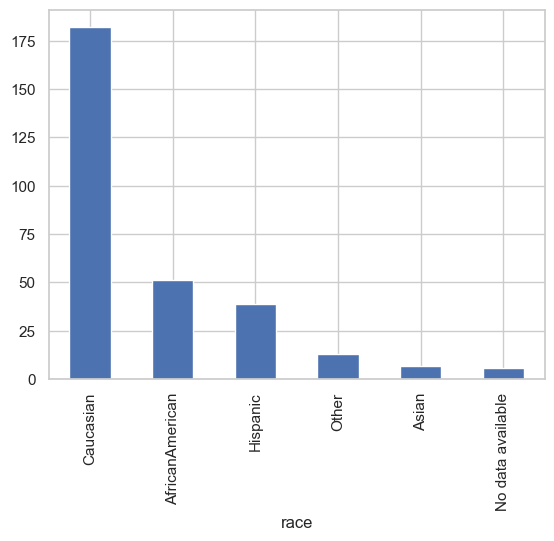

In [106]:
df['race'].value_counts().plot(kind='bar')

<h4 style="text-align:Left corner; color:Black;">
 This distribution indicates that the dataset is heavily dominated by one racial group, which may reflect the population demographics of the region or potential sampling bias. As a result, any analysis or conclusions drawn from this data should consider the lack of balanced racial representation, especially when generalizing findings across diverse populations.
</h4>

<h2 style="text-align:Left corner; color:Black;">
🎯 2. Hospital Stay Analysis (Core Focus)
</h2>

<h3 style="text-align:Left corner; color:Black;">
❓What is the overall distribution of hospital stay duration?
</h3>

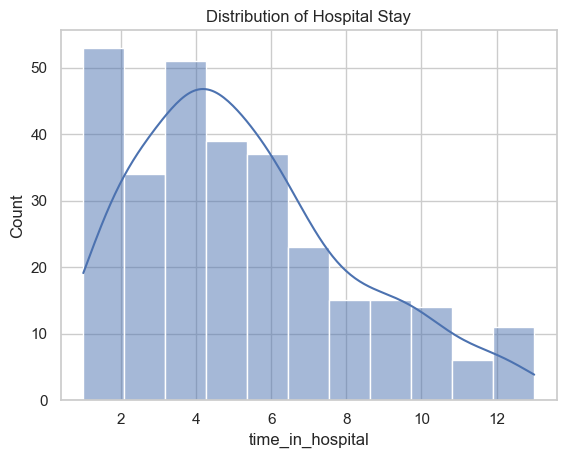

In [107]:
sns.histplot(df['time_in_hospital'], kde=True)
plt.title("Distribution of Hospital Stay")
plt.show()

<h4 style="text-align:Left corner; color:Black;">
The hospital stay analysis reveals a right-skewed distribution, indicating that the facility primarily handles short-term admissions. Most patients are discharged within 3 days, and there is a sharp decline in frequency for stays exceeding one week. This suggests that the hospital may be specialized in acute care or procedures with rapid recovery times, as long-term stays (10+ days) are outliers in the general dataset.
</h4>

<h3 style="text-align:Left corner; color:Black;">
❓Which age groups tend to stay longer in the hospital?
</h3>


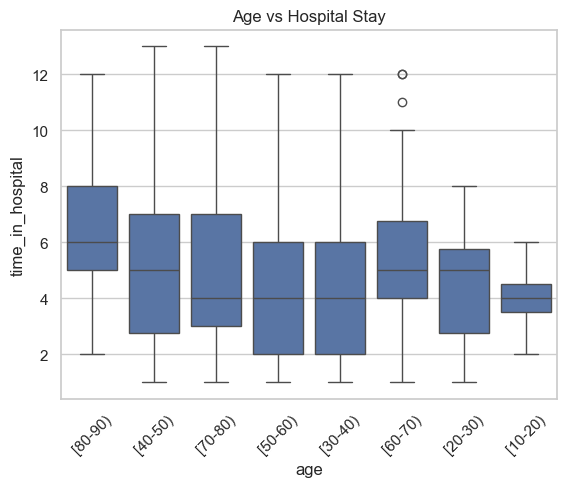

In [108]:
sns.boxplot(x='age', y='time_in_hospital', data=df)
plt.xticks(rotation=45)
plt.title("Age vs Hospital Stay")
plt.show()

<h4 style="text-align:Left corner; color:Black;">
Younger age groups (0–30) typically have shorter, more consistent stays, while patients over 50 tend to stay longer and show much higher variance in their recovery time.

<h3 style="text-align:Left corner; color:Black;">
❓Does gender influence hospital stay duration?
</h3>


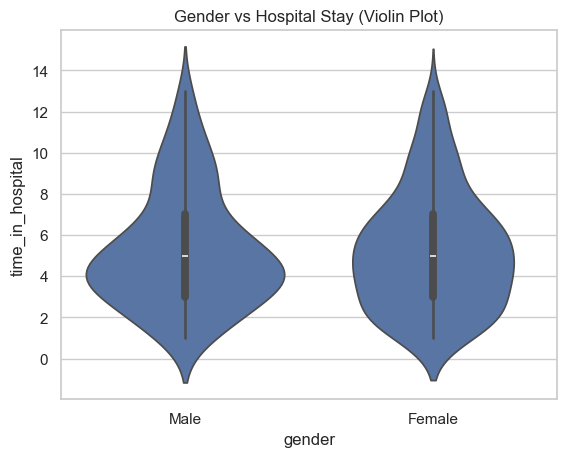

In [109]:
sns.violinplot(x='gender', y='time_in_hospital', data=df)
plt.title("Gender vs Hospital Stay (Violin Plot)")
plt.show()

<h4 style="text-align:Left corner; color:Black;">
Younger age groups (0–30) Gender does not appear to have a significant influence on hospital stay duration in this dataset. Any differences observed are minimal and likely not statistically meaningful.

<h2 style="text-align:Left corner; color:Black;">
👥 3. Demographic Insights
</h2>

<h3 style="text-align:Left corner; color:Black;">
❓What is the distribution of patients across different races?
</h3>

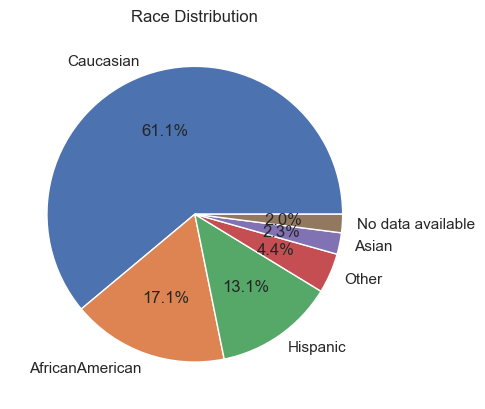

In [110]:
df['race'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Race Distribution")
plt.ylabel('')
plt.show()

<h4 style="text-align:Left corner; color:Black;">
The dataset shows a strong racial imbalance, with Caucasian patients comprising the majority, while other racial groups are significantly underrepresented
</h4>

<h3 style="text-align:Left corner; color:Black;">
❓Do different races show differences in hospital stay duration?
</h3>

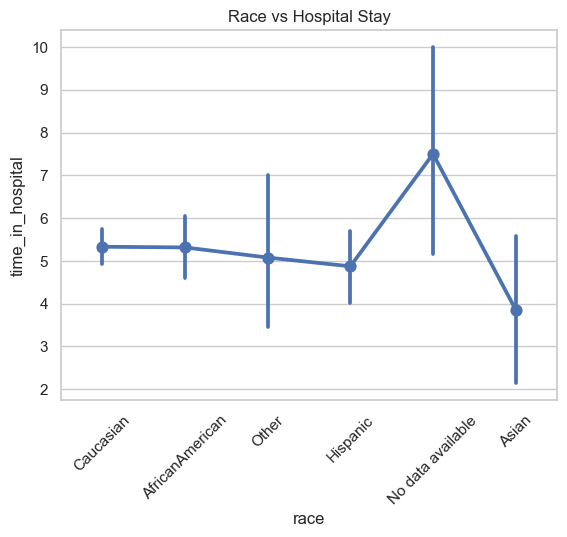

In [111]:
sns.pointplot(x='race', y='time_in_hospital', data=df)
plt.xticks(rotation=45)
plt.title("Race vs Hospital Stay")
plt.show()

<h4 style="text-align:Left corner; color:Black;">
Hospital stay duration is generally similar across races, with only minor variations and no significant differences observed
</h4>

<h2 style="text-align:Left corner; color:Black;">
📊 4. Discharge Analysis
</h2>

<h3 style="text-align:Left corner; color:Black;">
❓What are the most common discharge outcomes?
</h3>

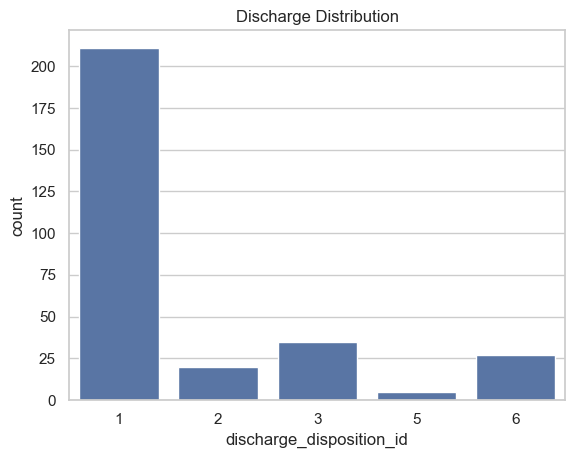

In [112]:
sns.countplot(x='discharge_disposition_id', data=df)
plt.title("Discharge Distribution")
plt.show()

<h4 style="text-align:Left corner; color:Black;">
Most patients fall under discharge category 1, making it the dominant outcome, while other discharge types are comparatively rare
</h4>

<h3 style="text-align:Left corner; color:Black;">
❓Does discharge type relate to hospital stay duration?
</h3>

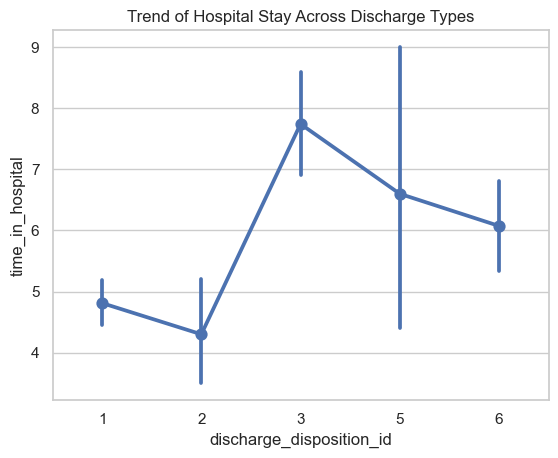

In [113]:
sns.pointplot(x='discharge_disposition_id', y='time_in_hospital', data=df)
plt.title("Trend of Hospital Stay Across Discharge Types")
plt.show()

<h2 style="text-align:Left corner; color:Black;">
🔬 5. Multivariate Analysis
</h2>

<h3 style="text-align:Left corner; color:Black;">
❓How do age and gender together influence hospital stay?
</h3>

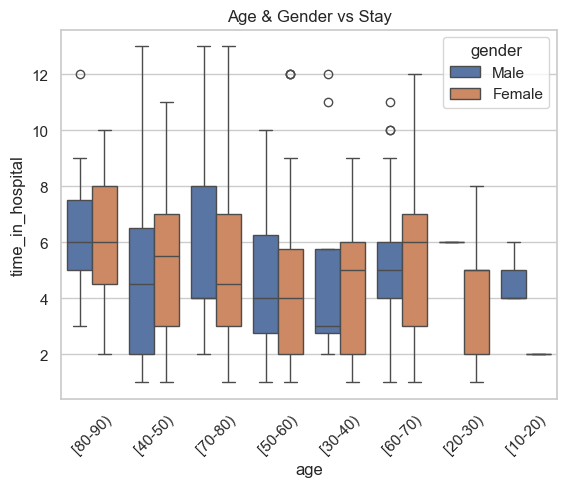

In [114]:
sns.boxplot(x='age', y='time_in_hospital', hue='gender', data=df)
plt.xticks(rotation=45)
plt.title("Age & Gender vs Stay")
plt.show()

<h3 style="text-align:Left corner; color:Black;">
❓What is the relationship between race and admission type?
</h3>

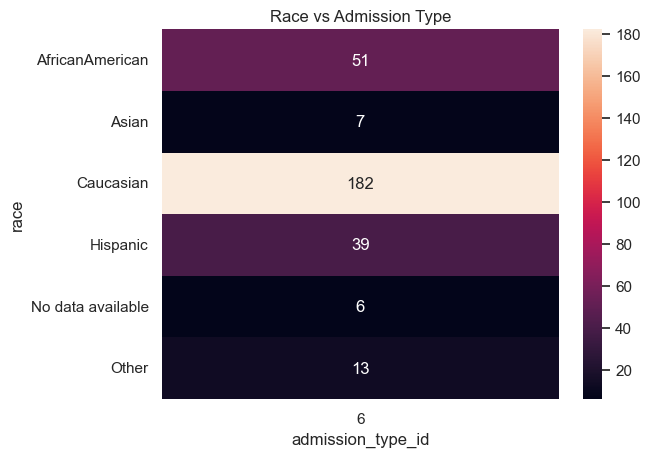

In [115]:
pivot = pd.crosstab(df['race'], df['admission_type_id'])
sns.heatmap(pivot, annot=True, fmt='d')
plt.title("Race vs Admission Type")
plt.show()

<h3 style="text-align:Left corner; color:Black;">
❓Which combination of features results in the longest hospital stay?
</h3>

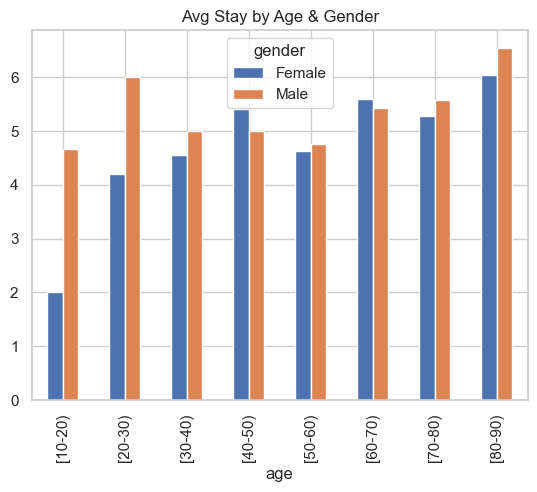

In [116]:
df.groupby(['age','gender'])['time_in_hospital'].mean().unstack().plot(kind='bar')
plt.title("Avg Stay by Age & Gender")
plt.show()

<h3 style="text-align:Left corner; color:Black;">
❓How does the number of lab procedures performed on a patient influence their duration of hospital stay?
</h3>

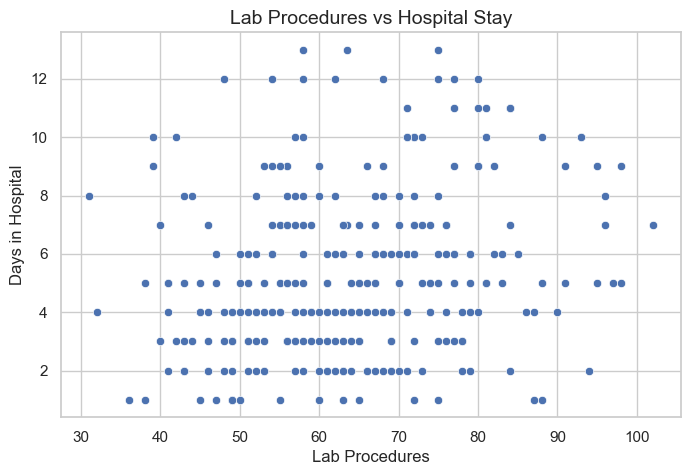

In [117]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='num_lab_procedures', y='time_in_hospital', data=df)
plt.title("Lab Procedures vs Hospital Stay", fontsize=14)
plt.xlabel("Lab Procedures")
plt.ylabel("Days in Hospital")
plt.show()

In [122]:
pip install plotly

Note: you may need to restart the kernel to use updated packages.


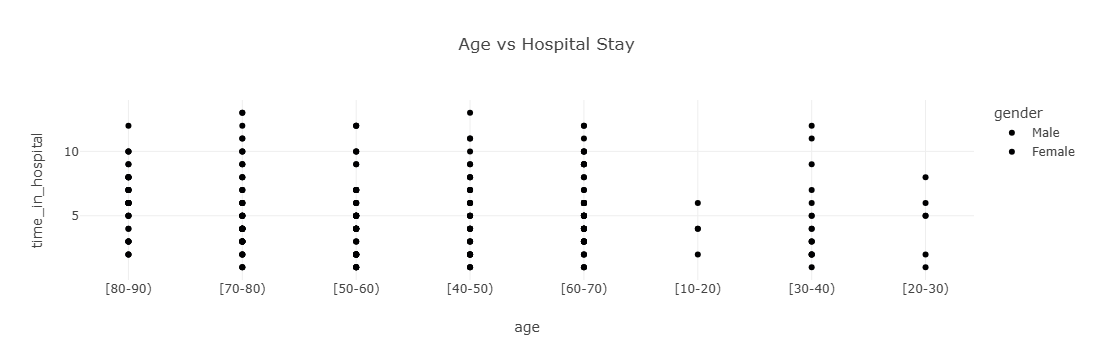

In [124]:
import plotly.express as px
import pandas as pd


fig = px.scatter(df,
                 x="age",
                 y="time_in_hospital",
                 color="gender",
                 title="Age vs Hospital Stay")

fig.show()

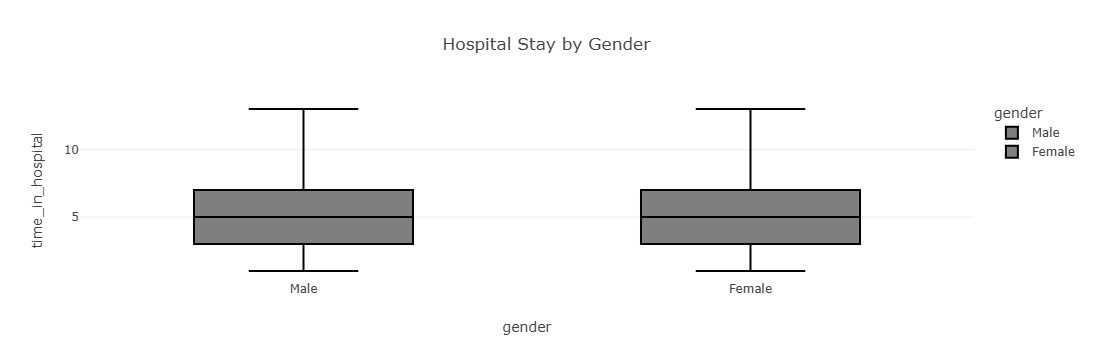

In [125]:
fig = px.box(df,
             x="gender",
             y="time_in_hospital",
             color="gender",
             title="Hospital Stay by Gender")

fig.show()

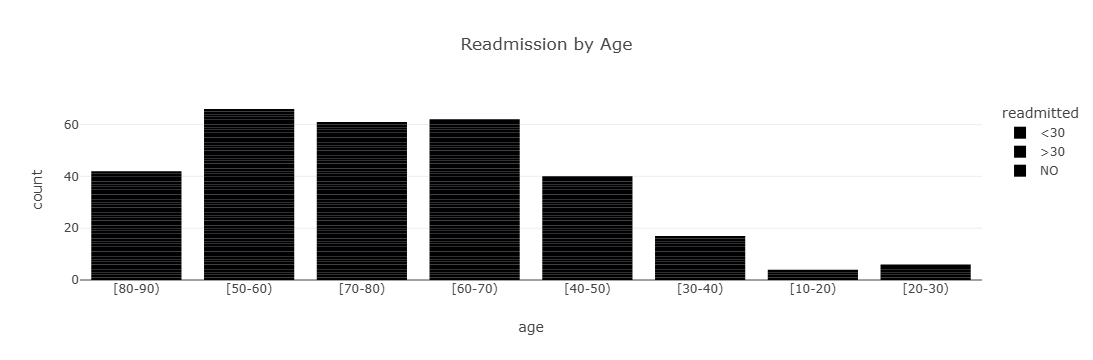

In [126]:
fig = px.bar(df,
             x="age",
             color="readmitted",
             title="Readmission by Age")

fig.show()

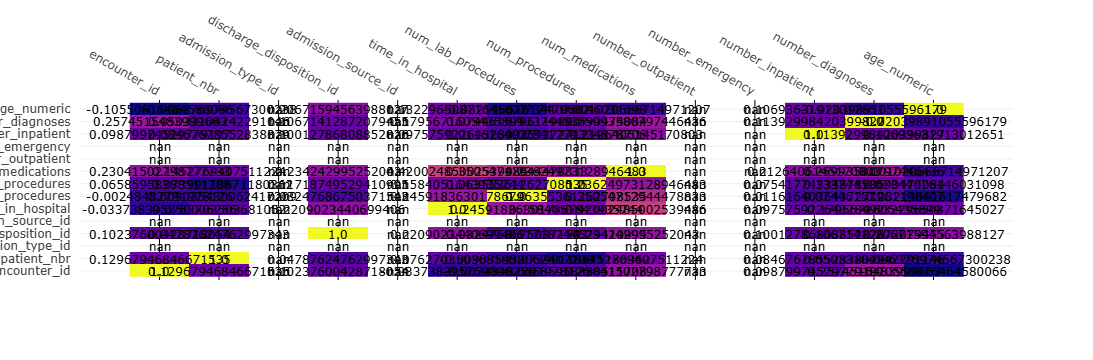

In [127]:
import plotly.figure_factory as ff

corr = df.corr(numeric_only=True)

fig = ff.create_annotated_heatmap(
    z=corr.values,
    x=list(corr.columns),
    y=list(corr.index)
)

fig.show()

<h2 style="text-align:center; color:red;">
Phase 5:  Insight Generation and Report  
</h2>

<div style="background-color:#d6ecff; padding:10px; border-radius:5px;">
<b style="color:black; font-size:18px;">📊 Exploratory Data Analysis - Diabetes Dataset</b>
</div>

This project analyzes a healthcare dataset related to diabetic patients.  
The objective is to identify patterns, trends, and relationships affecting hospital stay, readmission, and treatment outcomes.

<div style="background-color:#d6ecff; padding:10px; border-radius:5px;">
<b style="color:black; font-size:18px;">🧹 Data Cleaning</b>
</div>

- Replaced missing values ('?') with NaN  
- Standardized column names (lowercase, trimmed)  
- Removed duplicate records  
- Corrected data types  

<div style="background-color:#d6ecff; padding:10px; border-radius:5px;">
<b style="color:black; font-size:18px;">🔍 Univariate Analysis Insights</b>
</div>

- Most patients belong to middle and older age groups  
- Hospital stay is generally short (1–5 days)  
- Gender distribution is relatively balanced  
- Some diagnoses occur more frequently  

<div style="background-color:#d6ecff; padding:10px; border-radius:5px;">
<b style="color:black; font-size:18px;">🔗 Bivariate Analysis Insights</b>
</div>

- Older patients tend to stay longer in hospital  
- Readmission varies across age groups  
- Medication slightly reduces readmission rates  
- Gender has minimal impact on hospital stay

<div style="background-color:#d6ecff; padding:10px; border-radius:5px;">
<b style="color:black; font-size:18px;">📌 Multivariate Analysis Insights</b>
</div>

- Most variables show weak to moderate correlation  
- Hospital stay is influenced by multiple factors  
- No single variable strongly predicts readmission

<div style="background-color:#d6ecff; padding:10px; border-radius:5px;">
<b style="color:black; font-size:18px;">📈 Statistical Summary</b>
</div>

- Average hospital stay is relatively low  
- Some patients have longer stays indicating severe conditions  
- Data shows variability in patient health and treatment  

<div style="background-color:#d6ecff; padding:10px; border-radius:5px;">
<b style="color:black; font-size:18px;">💡 Key Insights</b>
</div>

- Most patients are older adults  
- Hospital stays are generally short  
- Readmission depends on age and treatment  
- Medication helps reduce readmission  
- Relationships are complex and not strongly linear  

<div style="background-color:#d6ecff; padding:10px; border-radius:5px;">
<b style="color:black; font-size:18px;">✅ Conclusion</b>
</div>

Patient age, treatment, and diagnosis significantly influence hospital stay and readmission.

Most patients recover quickly, but some require extended care.  
Improving treatment strategies and monitoring high-risk patients can reduce readmissions.

<div style="background-color:#d6ecff; padding:10px; border-radius:5px;">
<b style="color:black; font-size:18px;">🚀 Recommendations</b>
</div>

- Implement predictive models for high-risk patients  
- Improve follow-up care  
- Analyze medication effectiveness in more detail  
- Collect more detailed patient data  